# Type Segmentation

Notebook dedicado a aislar `PROYECTO EXTERNO`, `PROYECTO INTERNO` y `PRODUCTO`.

Objetivo:
- comparar cada tipo con sus propias metricas
- reconstruir forecast y bottlenecks por tipo
- evitar que un tipo distorsione al otro en la interpretacion operativa


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from IPython.display import display

project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.pipeline import run_baseline_pipeline
from src.type_segmentation import combine_type_tables, run_type_segmented_analysis

PATH_XLSX = project_root / "data" / "raw" / "DatosBusquedaAvanzada20250208.xlsx"

base_artifacts = run_baseline_pipeline(
    workbook_path=PATH_XLSX,
    rate_window_days=60,
    dashboard_horizon_days=5,
    scenario_horizons=(5, 10, 20),
)

segmented = run_type_segmented_analysis(
    base_artifacts["bm"],
    reference_date=base_artifacts["reference_date"],
    rate_window_days=60,
    dashboard_horizon_days=5,
    scenario_horizons=(5, 10, 20),
)

analysis_types = segmented["analysis_types"]
type_summary = segmented["type_summary"]
type_forecast_overview = segmented["type_forecast_overview"]
type_bottleneck_overview = segmented["type_bottleneck_overview"]

forecast_by_type = combine_type_tables(segmented, "forecast_dashboard_export")
owner_bottlenecks_by_type = combine_type_tables(segmented, "owner_bottlenecks")
task_alerts_by_type = combine_type_tables(segmented, "task_alerts")

analysis_types


['PROYECTO EXTERNO', 'PROYECTO INTERNO', 'PRODUCTO']

In [2]:
display(type_summary)
display(type_forecast_overview)
display(type_bottleneck_overview)


,type_name,n_rows,n_closed,n_open,owners,median_closed_duration_days,p90_closed_duration_days,median_open_age_days,max_open_age_days
0,PROYECTO INTERNO,365,349,16,13,4.01,14.78,212.52,331.51
1,PRODUCTO,210,194,16,10,14.88,74.86,84.70,270.70
2,PROYECTO EXTERNO,774,759,15,18,3.72,57.81,155.67,324.47


,type_name,owners_in_forecast,current_wip,forecast_wip,no_throughput_owners,overload_owners,risk_owners,healthy_owners
0,PROYECTO INTERNO,13,16.0,15.42,3,0,2,8
1,PROYECTO EXTERNO,18,15.0,13.75,1,0,5,12
2,PRODUCTO,10,13.0,11.99,3,0,3,4


,type_name,open_tasks,bottleneck_tasks,risk_tasks,healthy_tasks,bottleneck_owners,risk_owners,healthy_owners,top_problem_column
0,PROYECTO EXTERNO,15,8,6,1,4,2,0,En progreso
1,PROYECTO INTERNO,16,5,6,5,4,2,0,Backlog
2,PRODUCTO,16,4,8,4,5,1,1,Backlog


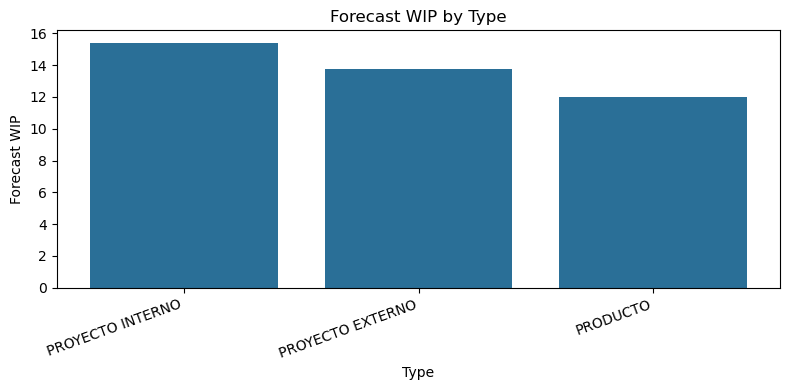

In [3]:
plt.figure(figsize=(8, 4))
plt.bar(type_forecast_overview["type_name"], type_forecast_overview["forecast_wip"], color="#2A6F97")
plt.title("Forecast WIP by Type")
plt.xlabel("Type")
plt.ylabel("Forecast WIP")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


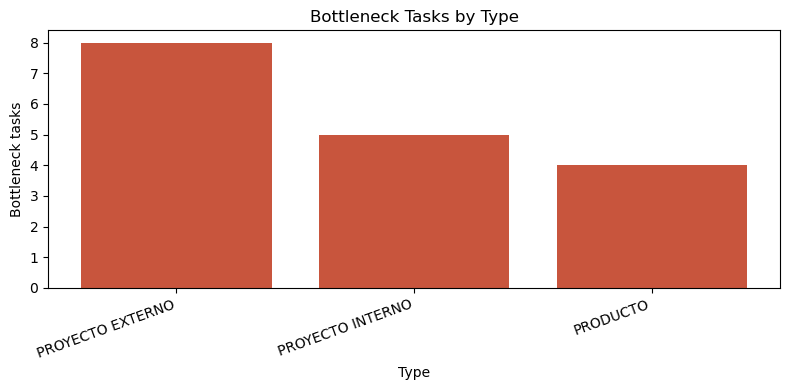

In [4]:
plt.figure(figsize=(8, 4))
plt.bar(type_bottleneck_overview["type_name"], type_bottleneck_overview["bottleneck_tasks"], color="#C8553D")
plt.title("Bottleneck Tasks by Type")
plt.xlabel("Type")
plt.ylabel("Bottleneck tasks")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


In [5]:
selected_type = "PROYECTO EXTERNO"
selected = segmented["type_artifacts"][selected_type]

display(selected["forecast_dashboard_export"])
display(selected["owner_bottlenecks"])
display(selected["column_bottlenecks"])
display(selected["task_alerts"].head(15))


,Owner,arrival_rate_per_day,completion_rate_per_day,current_wip,expected_arrivals,expected_completions,forecast_wip,status,status_reason
0,Consultor 2,0.02,0.00,1,0.08,0.00,1.08,no_throughput,open work but no recent completions
1,Consultor 4,0.00,0.05,5,0.00,0.25,4.75,risk,projected backlog exceeds horizon
2,Técnico 8,0.05,0.12,5,0.25,0.58,4.67,risk,projected backlog exceeds horizon
3,Consultor 6,0.00,0.05,2,0.00,0.25,1.75,risk,projected backlog exceeds horizon
4,Consultor 5,0.03,0.07,1,0.17,0.33,0.83,risk,projected backlog exceeds horizon
5,Consultor 1,0.02,0.08,1,0.08,0.42,0.67,risk,projected backlog exceeds horizon
6,Consultor 3,0.00,0.00,0,0.00,0.00,0.0,healthy,no recent load
7,Técnico 1,0.02,0.05,0,0.08,0.25,0.0,healthy,capacity aligned with horizon
8,Técnico 10,0.00,0.00,0,0.00,0.00,0.0,healthy,no recent load
9,Técnico 11,0.02,0.08,0,0.08,0.42,0.0,healthy,capacity aligned with horizon


,Owner,open_tasks,risk_tasks,bottleneck_tasks,old_open_tasks,stagnant_tasks,dependency_risk_tasks,complexity_risk_tasks,currently_blocked_tasks,historical_block_tasks,median_open_age_days,max_open_age_days,dominant_column,dominant_column_tasks,forecast_wip,forecast_status,forecast_status_reason,bottleneck_score,bottleneck_status
0,Técnico 8,5,1,4,1,0,0,0,4,4,100.45,317.71,En progreso,2,4.67,risk,projected backlog exceeds horizon,14,bottleneck
1,Consultor 4,5,2,3,2,2,0,0,2,2,236.70,317.27,En progreso,3,4.75,risk,projected backlog exceeds horizon,11,bottleneck
2,Consultor 6,2,1,1,1,1,0,0,1,1,217.49,324.47,En progreso,2,1.75,risk,projected backlog exceeds horizon,5,bottleneck
3,Consultor 2,1,0,0,0,0,0,0,0,0,43.65,43.65,En progreso,1,1.08,no_throughput,open work but no recent completions,1,bottleneck
4,Consultor 1,1,1,0,0,0,0,0,0,0,122.48,122.48,En progreso,1,0.67,risk,projected backlog exceeds horizon,2,risk
5,Consultor 5,1,1,0,0,0,0,0,0,0,155.67,155.67,Backlog,1,0.83,risk,projected backlog exceeds horizon,2,risk


,column_name,open_tasks,risk_tasks,bottleneck_tasks,owners_involved,median_age_days,max_age_days,mean_days_since_last_moved,dependency_risk_tasks,currently_blocked_tasks,historical_block_tasks,bottleneck_status
0,En progreso,9,3,5,5,236.70,324.47,168.57,0,4,4,bottleneck
1,Pilotos / Batería de pruebas,2,1,1,2,146.98,193.50,5.00,0,1,1,bottleneck
2,A empezar,1,0,1,1,193.50,193.50,157.00,0,1,1,bottleneck
3,Testeos internos,1,0,1,1,74.58,74.58,59.00,0,1,1,bottleneck
4,Backlog,2,2,0,2,125.59,155.67,NaN,0,0,0,risk


,Card ID,Owner,Column Name,task_status,Type Name,age_days,days_since_last_moved,subtasks_count,has_any_links,owner_forecast_wip,...,owner_forecast_status_reason,benchmark_source,benchmark_median_days,benchmark_p90_days,age_vs_benchmark,blocked_state,block_time_hours,alert_score,alert_level,alert_reason
0,4876,Consultor 6,En progreso,in_progress,PROYECTO EXTERNO,324.47,277.0,0.0,0,1.75,...,projected backlog exceeds horizon,owner_type,18.19,189.59,17.84,yes,2303.93,8,bottleneck,old_open; stagnant; older_than_history; curren...
1,5108,Técnico 8,En progreso,in_progress,PROYECTO EXTERNO,317.71,115.0,0.0,0,4.67,...,projected backlog exceeds horizon,owner_type,2.15,33.43,147.52,yes,2763.35,6,bottleneck,old_open; older_than_history; currently_blocke...
2,5191,Consultor 4,En progreso,in_progress,PROYECTO EXTERNO,317.27,118.0,0.0,0,4.75,...,projected backlog exceeds horizon,owner_type,21.83,98.73,14.53,yes,2564.17,6,bottleneck,old_open; older_than_history; currently_blocke...
3,5948,Consultor 4,En progreso,in_progress,PROYECTO EXTERNO,290.51,285.0,0.0,0,4.75,...,projected backlog exceeds horizon,owner_type,21.83,98.73,13.31,no,0.00,5,bottleneck,old_open; stagnant; older_than_history; owner_...
4,8079,Consultor 4,A empezar,open,PROYECTO EXTERNO,193.50,157.0,0.0,0,4.75,...,projected backlog exceeds horizon,owner_type,21.83,98.73,8.86,yes,2996.88,5,bottleneck,older_than_history; currently_blocked; owner_risk
5,9699,Técnico 8,En progreso,in_progress,PROYECTO EXTERNO,106.70,93.0,0.0,0,4.67,...,projected backlog exceeds horizon,owner_type,2.15,33.43,49.54,yes,2301.93,5,bottleneck,older_than_history; currently_blocked; owner_risk
6,9880,Técnico 8,Pilotos / Batería de pruebas,in_progress,PROYECTO EXTERNO,100.45,NaN,0.0,0,4.67,...,projected backlog exceeds horizon,owner_type,2.15,33.43,46.64,yes,576.02,5,bottleneck,older_than_history; currently_blocked; owner_risk
7,11184,Técnico 8,Testeos internos,in_progress,PROYECTO EXTERNO,74.58,59.0,0.0,0,4.67,...,projected backlog exceeds horizon,owner_type,2.15,33.43,34.63,yes,119.12,5,bottleneck,older_than_history; currently_blocked; owner_risk
8,7314,Consultor 4,En progreso,in_progress,PROYECTO EXTERNO,236.70,237.0,0.0,0,4.75,...,projected backlog exceeds horizon,owner_type,21.83,98.73,10.84,no,0.00,4,risk,stagnant; older_than_history; owner_risk
9,8067,Consultor 4,Pilotos / Batería de pruebas,in_progress,PROYECTO EXTERNO,193.50,5.0,0.0,0,4.75,...,projected backlog exceeds horizon,owner_type,21.83,98.73,8.86,no,0.00,2,risk,older_than_history; owner_risk


In [6]:
forecast_by_type.sort_values(["analysis_type", "forecast_wip"], ascending=[True, False]).head(20)


,analysis_type,Owner,arrival_rate_per_day,completion_rate_per_day,current_wip,expected_arrivals,expected_completions,forecast_wip,status,status_reason
34,PRODUCTO,Técnico 4,0.03,0.17,5,0.17,0.83,4.33,risk,projected backlog exceeds horizon
35,PRODUCTO,Técnico 7,0.03,0.07,4,0.17,0.33,3.83,risk,projected backlog exceeds horizon
31,PRODUCTO,Consultor 1,0.02,0.00,1,0.08,0.00,1.08,no_throughput,open work but no recent completions
32,PRODUCTO,Comercial 2,0.00,0.00,1,0.00,0.00,1.0,no_throughput,open work but no recent completions
33,PRODUCTO,Técnico 6,0.00,0.00,1,0.00,0.00,1.0,no_throughput,open work but no recent completions
36,PRODUCTO,Consultor 4,0.00,0.05,1,0.00,0.25,0.75,risk,projected backlog exceeds horizon
37,PRODUCTO,Consultor 6,0.00,0.00,0,0.00,0.00,0.0,healthy,no recent load
38,PRODUCTO,Técnico 1,0.00,0.02,0,0.00,0.08,0.0,healthy,capacity aligned with horizon
39,PRODUCTO,Técnico 3,0.00,0.07,0,0.00,0.33,0.0,healthy,capacity aligned with horizon
40,PRODUCTO,Técnico 8,0.00,0.00,0,0.00,0.00,0.0,healthy,no recent load


In [7]:
owner_bottlenecks_by_type.sort_values(["analysis_type", "bottleneck_score"], ascending=[True, False]).head(20)


,analysis_type,Owner,open_tasks,risk_tasks,bottleneck_tasks,old_open_tasks,stagnant_tasks,dependency_risk_tasks,complexity_risk_tasks,currently_blocked_tasks,historical_block_tasks,median_open_age_days,max_open_age_days,dominant_column,dominant_column_tasks,forecast_wip,forecast_status,forecast_status_reason,bottleneck_score,bottleneck_status
12,PRODUCTO,Técnico 7,4,1,3,3,3,3,0,0,4,247.35,247.36,Backlog,4,3.83,risk,projected backlog exceeds horizon,11,bottleneck
17,PRODUCTO,Técnico 4,5,5,0,0,0,0,0,0,0,82.64,86.76,Testeos internos,4,4.33,risk,projected backlog exceeds horizon,6,risk
13,PRODUCTO,Consultor 4,1,0,1,1,1,1,1,0,0,270.70,270.70,Backlog,1,0.75,risk,projected backlog exceeds horizon,4,bottleneck
14,PRODUCTO,Comercial 2,1,1,0,0,0,0,0,0,0,67.70,67.70,Testeos internos,1,1.0,no_throughput,open work but no recent completions,2,bottleneck
15,PRODUCTO,Técnico 6,1,1,0,0,0,0,0,0,0,81.65,81.65,Backlog,1,1.0,no_throughput,open work but no recent completions,2,bottleneck
16,PRODUCTO,Consultor 1,1,0,0,0,0,0,0,0,0,50.60,50.60,Backlog,1,1.08,no_throughput,open work but no recent completions,1,bottleneck
18,PRODUCTO,UNASSIGNED,3,0,0,0,0,0,0,0,0,93.65,103.46,Backlog,3,0.0,healthy,capacity aligned with horizon,0,healthy
0,PROYECTO EXTERNO,Técnico 8,5,1,4,1,0,0,0,4,4,100.45,317.71,En progreso,2,4.67,risk,projected backlog exceeds horizon,14,bottleneck
1,PROYECTO EXTERNO,Consultor 4,5,2,3,2,2,0,0,2,2,236.70,317.27,En progreso,3,4.75,risk,projected backlog exceeds horizon,11,bottleneck
2,PROYECTO EXTERNO,Consultor 6,2,1,1,1,1,0,0,1,1,217.49,324.47,En progreso,2,1.75,risk,projected backlog exceeds horizon,5,bottleneck
